# NOTE
- While this entry task focuses on simple and interpretable features, I am comfortable working with more advanced approaches, including deep learning and multi-modal modeling. I chose to keep the implementation straightforward to align with the task requirements and ensure clarity and reproducibility.

- If given the opportunity to work on the full project, I would be excited to work with more sophisticated techniques such as spatiotemporal models, improved feature extraction, and multi-modal integration to achieve higher accuracy and deeper behavioral understanding.
- I already have a lot of experience in this field

THIS JUPYTER FILE IS USED TO EXTRACT FEATURE LIKE MOTION MAGNITUDE AND CONTOUR AREA (BOUNDING BOX AREA) WITHOUT USING ANY SPECIALIZED MODEL LIKE( ID3 COVNET , SLOWFAST AND MANY OTHERS)
IT USES SIMPLE PYTHON CODE TO PRODUCE AN ANALYSIS FOR THE GIVEN VIDEO



 Load the video and Extract the Metadata

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_path = "DATASETS/3836204455-preview.mp4"                      # FUCNTION USED TO OPEN VIDEO
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError("Cannot open video")                              

# OPENCV USED TO CALUCLATE THE META DATA

fps = cap.get(cv2.CAP_PROP_FPS)                                   # FUNCTIONS USED TO READ THE META DATA OF THE VIDEO
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = total_frames / fps                                      # TOTAL VIDEO LENGTH IN SECONDS

# PRINTING THE RESULTS
#                                                                
print(f"Resolution: {width}x{height}")
print(f"FPS: {fps}")
print(f"Total frames: {total_frames}")
print(f"Duration (seconds): {duration:.2f}")

Resolution: 898x506
FPS: 29.97002997002997
Total frames: 749
Duration (seconds): 24.99


Extracting the First Features From the video

In [44]:

resize_shape = (224, 224)                              # OPTIONAL: RESIZE FOR FASTER COMPUTATION

# INITIALIZING ARRAYS TO STORE FEATURES

motion_feats = []
contour_areas = []
time_stamps = []
frame_idx = 0                            #KEEPS TRACK OF FRAME NUMBER

# READ THE FIRST FRAME 

read_true, prev_frame = cap.read()
if not read_true:
    raise RuntimeError("Cannot read video")
prev_frame = cv2.resize(prev_frame, resize_shape)
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

# LOOP THROUGH FRAMES

while True:
    read_true, frame = cap.read()
    if not read_true:
        break

    frame = cv2.resize(frame, resize_shape)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    #  EXTRACTING FIRST FEATURE
    motion_val = np.sum(cv2.absdiff(prev_gray, gray))
    motion_feats.append(motion_val)
    prev_gray = gray

    # EXTRACTING SECOND FEATURE
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        max_area = max(cv2.contourArea(c) for c in contours)
    else:
        max_area = 0
    contour_areas.append(max_area)

    time_stamps.append(frame_idx / fps)
    frame_idx += 1

cap.release()

# CONVERT TO NUMPY ARRAYS
motion_feats = np.array(motion_feats)
contour_areas = np.array(contour_areas)
time_stamps = np.array(time_stamps)

print("Feature extraction complete!")
print(motion_feats.shape)
print(contour_areas.shape)
print(time_stamps.shape)

Feature extraction complete!
(748,)
(748,)
(748,)


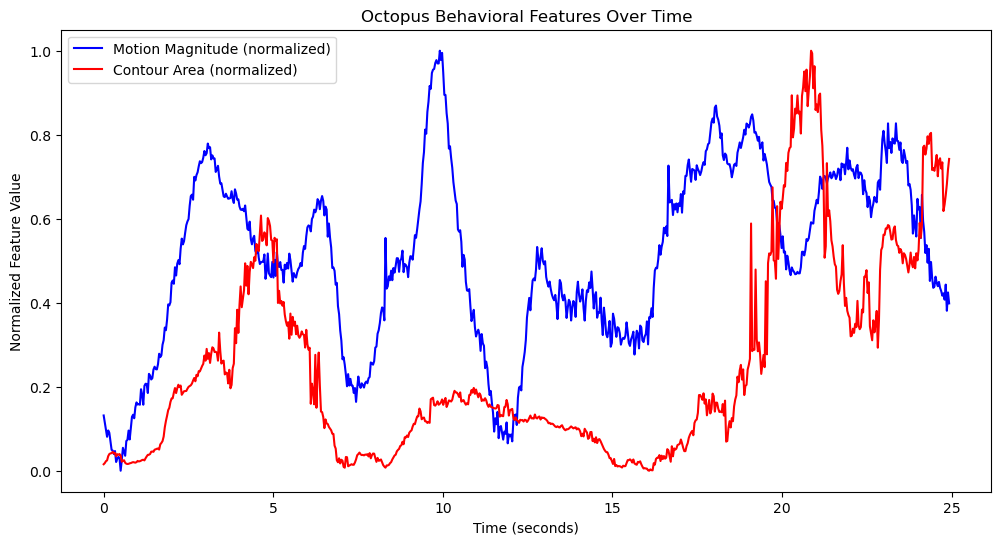

In [ ]:


# NORMILIZING FOR VISUALIZATION
motion_norm = (motion_feats - motion_feats.min()) / (motion_feats.max() - motion_feats.min())
contour_norm = (contour_areas - contour_areas.min()) / (contour_areas.max() - contour_areas.min())

plt.figure(figsize=(12,6))
plt.plot(time_stamps, motion_norm, label="Motion Magnitude (normalized)", color="blue")
plt.plot(time_stamps, contour_norm, label="Contour Area (normalized)", color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Feature Value")
plt.title("Octopus Behavioral Features Over Time")
plt.legend()
plt.show()


# PLEASE CHECK THE BELOW SHORT ANALYSIS 

Results & Visualizations

- Blue line — normalized motion magnitude over time, showing activity bursts and quiet periods
- Red line — normalized contour area over time, showing body expansion and contraction events

Regions where both lines are elevated together indicate active, expanded behavior. Regions where both are suppressed indicate resting or hiding. Divergence between the two lines reveals postural changes without locomotion (or vice versa).

 # Short Analysis


---

##  Extracted Features

###  1. Motion Magnitude
- Motion magnitude measures the **amount of movement between consecutive frames**.
- It is computed using the **absolute difference between frames** and summing pixel changes.

####  Interpretation:
- **High motion** → active behavior (exploration, reaction, stress)
- **Low motion** → minimal activity (resting, camouflaging)

 This feature answers:  
**"How much is the octopus moving?"**

---

###  2. Contour Area
- Contour area represents the **visible size of the octopus in the frame**.
- It is computed by detecting contours and selecting the **largest contour area**.

####  Interpretation:
- **Large contour area** → body stretched or expanded 
- could mean : active, alert, displaying ,reacting
- **Small contour area** → body curled, compact, or hidden
- could mean : resting , hiding camouflaging

 This feature answers:  
**"What is the body posture of the octopus?"**

---

##  Behavioral Understanding (Combined Features)

Individually, each feature provides limited information. However, when combined, they provide a more complete understanding of behavior.

| Motion Magnitude | Contour Area | Behavioral Interpretation |
|-----------------|-------------|--------------------------|
| High            | High        | Active response, exploration, or stress |
| High            | Low         | Quick or cautious movement |
| Low             | High        | Alert but stationary behavior |
| Low             | Low         | Resting, hiding, or camouflaging |

 **Key Insight:**  
- Motion magnitude represents **activity**
- Contour area represents **posture**
- Together, they describe **behavior**

---

##  What These Features Tell Us

- They allow identification of **periods of activity and inactivity**
- They help distinguish between **movement-based and posture-based behaviors**
- They provide a **simple and interpretable way to analyze behavior over time**

---

##  Limitations

Despite being useful, these features have several limitations:
- Motion magnitude cannot distinguish **what is moving** (octopus vs background noise)
- Contour detection may be affected by **lighting and background conditions**
- They do not capture:
  - Fine-grained limb movements (e.g., tentacles)
  - Color or texture changes
  - Environmental triggers
- Behavioral interpretation is **approximate**, not precise

---

##  Improvements with Additional Modalities

To improve analysis, additional data sources (modalities) can be incorporated:
###  1. Audio
- Captures **water disturbance ,external noise**
- Helps in answering  **Did something in the environment cause this reaction?**
###  2. Posture Estimation
- Instead of just size tracks body parts (e.g., tentacles)
- Provides **detailed structural understanding of movement**
###  3. Color and Texture Analysis
- Octopuses change color for camouflage and signaling
- Helps infer **emotional or behavioral state**
###  4. Environmental Context
- Detects objects or changes in surroundings
- Helps explain **why a behavior occurred**
###  5. Temporal Patterns
- Analyzes behavior over time
- Helps identify **trends and sudden reactions**



# Conclusion

- Current features provide a **basic understanding of behavior**
- Additional modalities provide **context, detail, and causation**

